In [95]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from cd.utils.signals import *

In [ ]:
def duffing(t, y, delta, alpha, beta, gamma, omega):
    """
    delta: damping
    alpha: linear stiffness
    beta: nonlinear stiffness
    gamma: forcing amplitude
    omega: forcing freq
    """
    x, v = y
    dxdt = v
    dvdt = -delta * v - alpha * x - beta * x**3 + gamma * np.cos(omega * t)
    return [dxdt, dvdt]

In [93]:
def simulate_duffing(x0, v0, delta, alpha, beta, gamma, omega, t_max=200):
    t_eval = np.linspace(0, t_max, 5000)
    
    sol = solve_ivp(
        duffing,
        [0, t_max],
        [x0, v0],
        t_eval=t_eval,
        args=(delta, alpha, beta, gamma, omega),
        rtol=1e-9, atol=1e-9
    )
    
    return sol.t, sol.y[0], sol.y[1]

def plot_duffing(x0, v0, delta, alpha, beta, gamma, omega):
    t, x, v = simulate_duffing(x0, v0, delta, alpha, beta, gamma, omega)

    plt.figure(figsize=(10,4))
    plt.plot(t, x)
    plt.xlabel("time")
    plt.ylabel("x(t)")
    plt.title("Duffing Oscillator")
    plt.grid(True)
    plt.show()

    return x

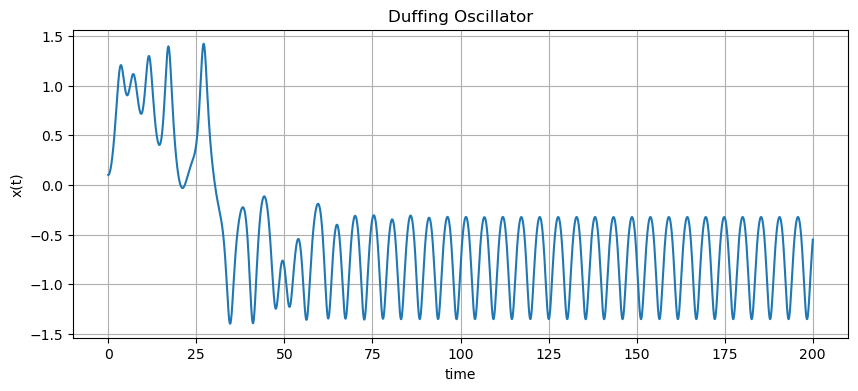

In [136]:
x = plot_duffing(
    x0=0.1,
    v0=0.0,
    delta=0.2,
    alpha=-1.0,
    beta=1.0,
    gamma=0.2,
    omega=1.2
)


est. freq.: 0.008


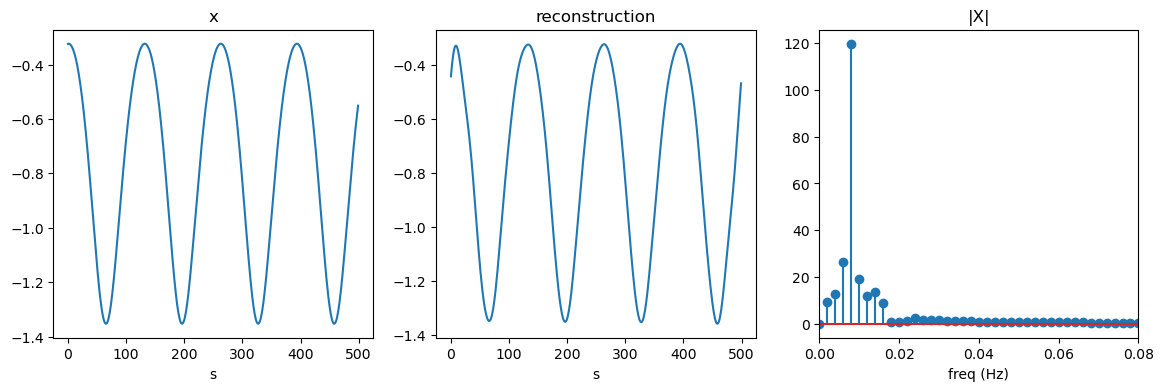

In [133]:
analyze(x[-500:])

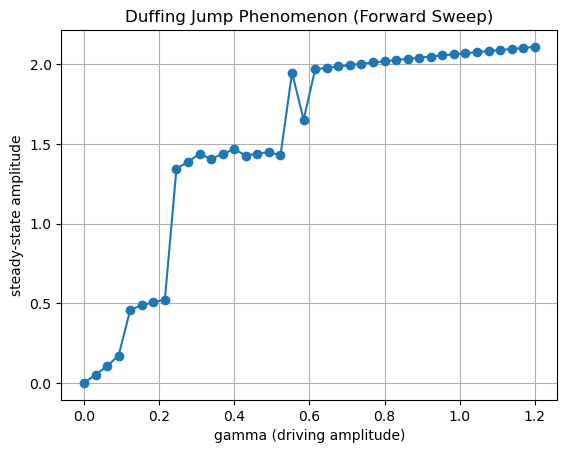

In [78]:
def amplitude_after_transient(x):
    # estimate amplitude from last 10% of data
    return (np.max(x[-500:]) - np.min(x[-500:])) / 2

gammas = np.linspace(0, 1.2, 40)
amps = []
x0, v0 = 0.1, 0.0

for gamma in gammas:
    t, x, v = simulate_duffing(
        x0, v0,
        delta=0.2, alpha=-1.0, beta=1.0,
        gamma=gamma, omega=1.2,
        t_max=300
    )
    amps.append(amplitude_after_transient(x))
    # use final state as new initial condition (important!)
    x0, v0 = x[-1], v[-1]

plt.plot(gammas, amps, '-o')
plt.xlabel("gamma (driving amplitude)")
plt.ylabel("steady-state amplitude")
plt.title("Duffing Jump Phenomenon (Forward Sweep)")
plt.grid(True)
plt.show()
